In [1]:
import pandas as pd
import numpy as np
import os

file_path = "datasets/madalena_processed_30min"

def feature_engineer(file_path):
    df = pd.read_csv(file_path)
    df = df.loc[:, ~df.columns.str.startswith('Unnamed:')]    
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df.set_index('timestamp', inplace=True)
    df = df.sort_index()
    df['day_of_year'] = df.index.dayofyear
    df['season'] = df.index.month % 12 // 3
    df['month'] = df.index.month
    df['day_of_week'] = df.index.weekday
    df['hour'] = df.index.hour
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 48)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 48)

    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    df['is_weekend'] = (df.index.weekday >= 5).astype(int)
    df['energy_lag_48'] = df['total_energy'].shift(48).fillna(method='bfill')
    df['energy_lag_96'] = df['total_energy'].shift(96).fillna(method='bfill')
    df['energy_lag_1'] = df['total_energy'].shift(1).fillna(method='bfill')
    df['energy_diff'] = df['total_energy'].diff().fillna(method='bfill')
    df['max_energy'] = df['total_energy'].rolling(window=48).max().fillna(method='bfill')
    df['min_energy'] = df['total_energy'].rolling(window=48).min().fillna(method='bfill')
    df['energy_diff_daily'] = df['max_energy'] - df['min_energy'] 
    df['energy_rolling'] = df['total_energy'].rolling(window=24).mean().fillna(method='bfill')
    df['Tout_diff'] = df['Tout'].diff().fillna(method="bfill")
    df['Tout_lag_1'] = df['Tout'].shift(1).fillna(method='bfill')
    df['Tout_lag_2'] = df['Tout'].shift(2).fillna(method='bfill')
    df['energy_std_48'] = df['total_energy'].rolling(window=48).std().fillna(method='bfill')
    df['energy_spike'] = (df['total_energy'] > df['total_energy'].rolling(window=48).mean().fillna(method='bfill') + 3*df['total_energy'].rolling(window=48).std().fillna(method='bfill')).astype(float)
    df['rolling_max_3h'] = df['total_energy'].rolling(window=6).max().fillna(method='bfill')
    df['recent_spike'] = df['total_energy'].diff().abs().rolling(2).max() > 200

    return df

In [2]:
import torch
from torch.utils.data import TensorDataset, DataLoader


def create_mimo_sequences(data, input_len=96, output_len=48):
    X, y = [], []
    for i in range(len(data) - input_len - output_len):
        X.append(data[i:i+input_len])
        y.append(data[i+input_len:i+input_len+output_len, 0]) 
        # spike_targets.append(spike_data[i+input_len:i+input_len+output_len])
    return np.array(X), np.array(y)

C:\Users\Kelsier\AppData\Local\Temp\ipykernel_16908\2884819306.py:24: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['energy_lag_48'] = df['total_energy'].shift(48).fillna(method='bfill')
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_16908\2884819306.py:25: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['energy_lag_96'] = df['total_energy'].shift(96).fillna(method='bfill')
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_16908\2884819306.py:26: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['energy_lag_1'] = df['total_energy'].shift(1).fillna(method='bfill')
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_16908\2884819306.py:27: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Us

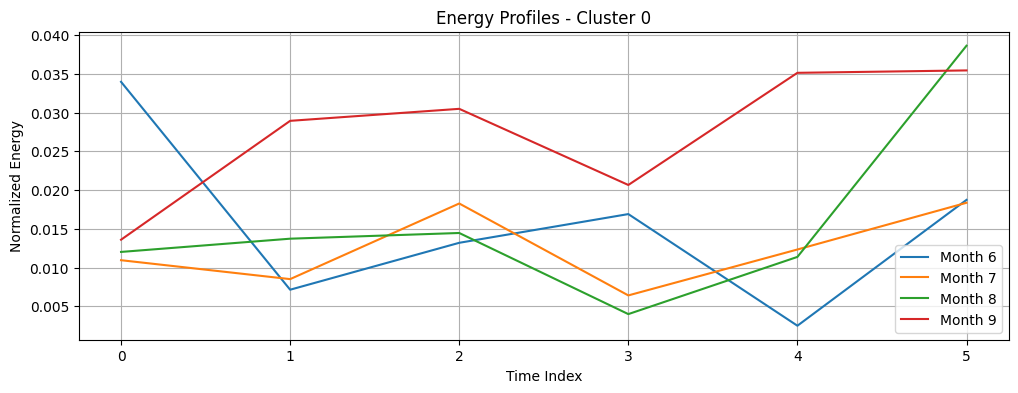

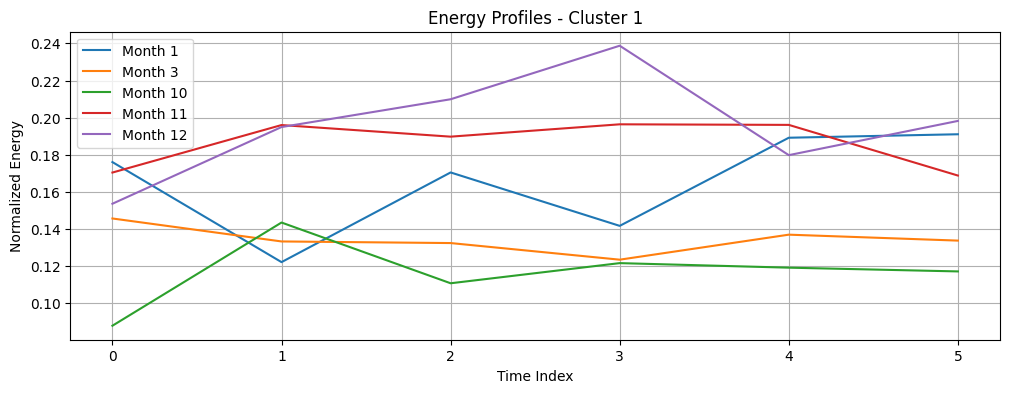

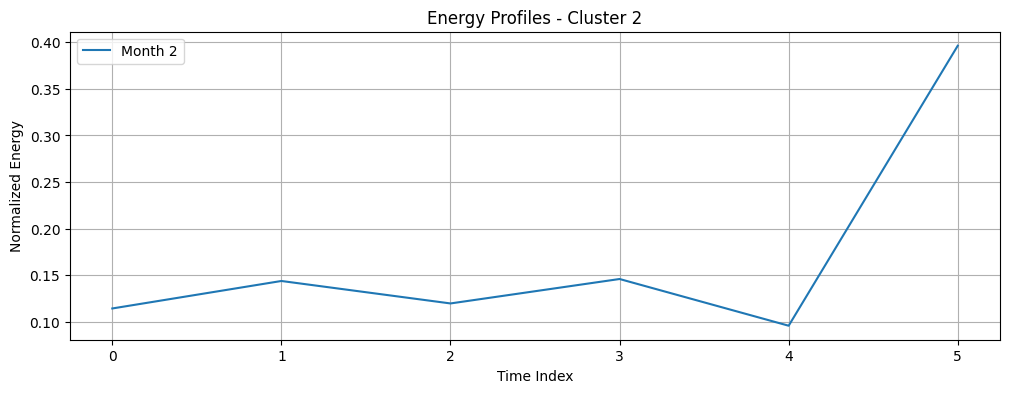

C:\Users\Kelsier\AppData\Local\Temp\ipykernel_16908\3314992363.py:60: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['rolling_mean_6'] = df['total_energy'].rolling(8).mean().fillna(method='bfill')
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_16908\3314992363.py:61: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['rolling_std_6'] = df['total_energy'].rolling(8).std().fillna(method='bfill')
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_16908\3314992363.py:62: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['energy_lag_336'] = df['total_energy'].shift(336).fillna(method='bfill')
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_16908\3314992363.py:63: FutureWarning: Series.fillna with 'method' is deprecated and will raise in 

Epoch 1/100 | Train Loss: 0.008845 | Val Loss: 0.007146
Epoch 2/100 | Train Loss: 0.007221 | Val Loss: 0.006822
Epoch 3/100 | Train Loss: 0.007111 | Val Loss: 0.006719
Epoch 4/100 | Train Loss: 0.006995 | Val Loss: 0.007064
Epoch 5/100 | Train Loss: 0.006763 | Val Loss: 0.006548
Epoch 6/100 | Train Loss: 0.006625 | Val Loss: 0.006395
Epoch 7/100 | Train Loss: 0.006519 | Val Loss: 0.006397
Epoch 8/100 | Train Loss: 0.006509 | Val Loss: 0.006371
Epoch 9/100 | Train Loss: 0.006404 | Val Loss: 0.006277
Epoch 10/100 | Train Loss: 0.006328 | Val Loss: 0.006231
Epoch 11/100 | Train Loss: 0.006203 | Val Loss: 0.006034
Epoch 12/100 | Train Loss: 0.006098 | Val Loss: 0.006037
Epoch 13/100 | Train Loss: 0.005971 | Val Loss: 0.005869
Epoch 14/100 | Train Loss: 0.006022 | Val Loss: 0.005775
Epoch 15/100 | Train Loss: 0.005806 | Val Loss: 0.005633
Epoch 16/100 | Train Loss: 0.005486 | Val Loss: 0.005365
Epoch 17/100 | Train Loss: 0.005325 | Val Loss: 0.005264
Epoch 18/100 | Train Loss: 0.005240 | Va

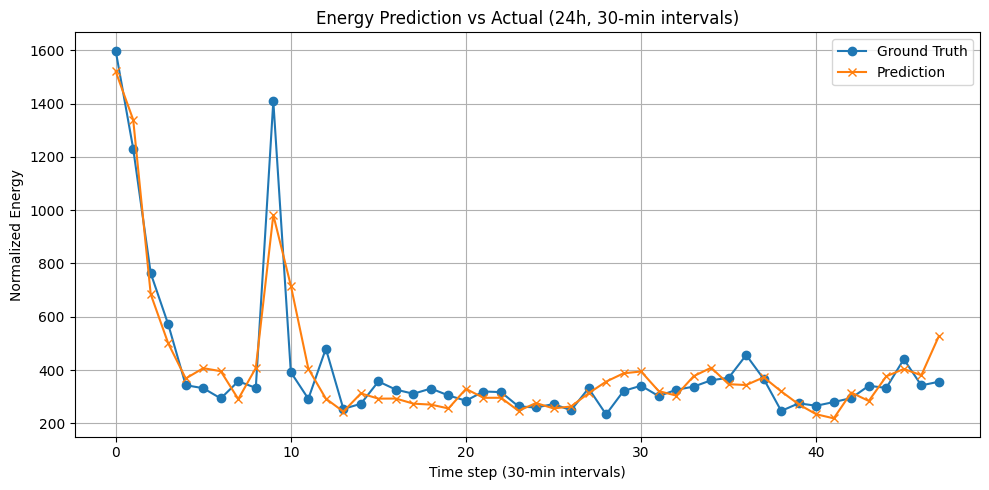

C:\Users\Kelsier\AppData\Local\Temp\ipykernel_16908\2884819306.py:24: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['energy_lag_48'] = df['total_energy'].shift(48).fillna(method='bfill')
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_16908\2884819306.py:25: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['energy_lag_96'] = df['total_energy'].shift(96).fillna(method='bfill')
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_16908\2884819306.py:26: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['energy_lag_1'] = df['total_energy'].shift(1).fillna(method='bfill')
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_16908\2884819306.py:27: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Us

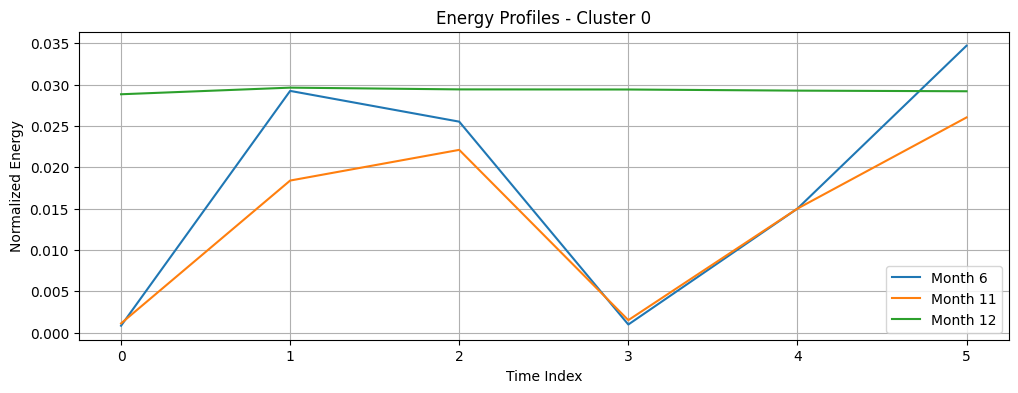

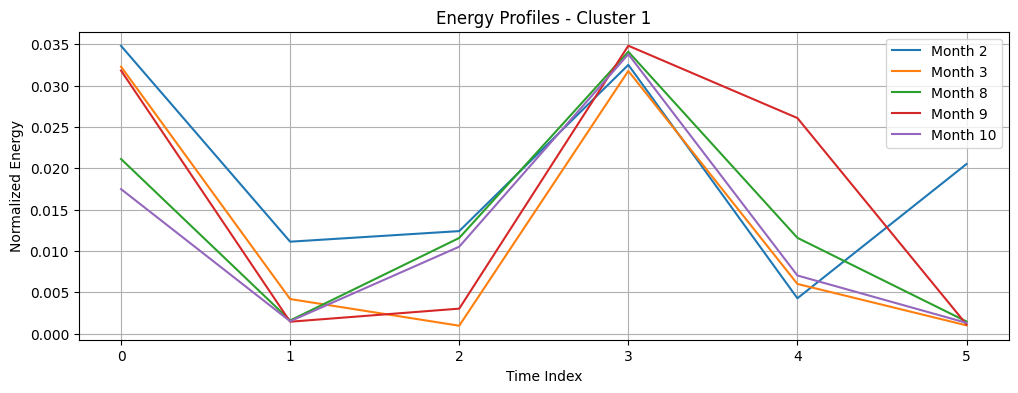

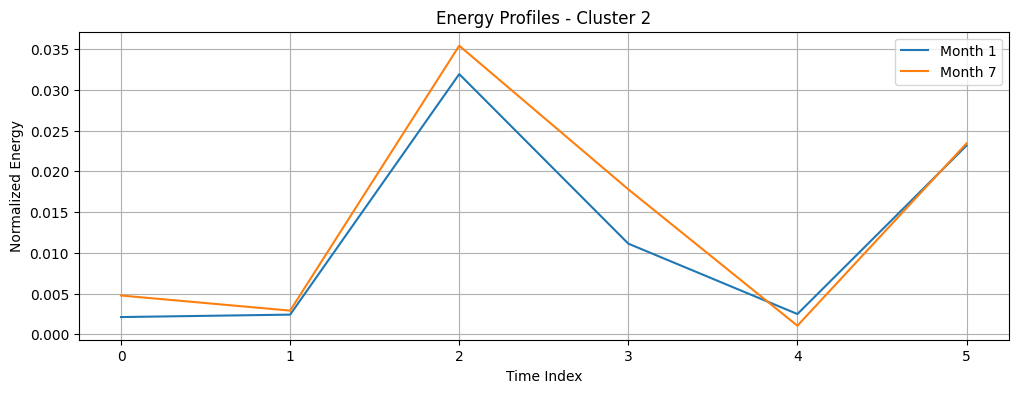

C:\Users\Kelsier\AppData\Local\Temp\ipykernel_16908\3314992363.py:60: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['rolling_mean_6'] = df['total_energy'].rolling(8).mean().fillna(method='bfill')
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_16908\3314992363.py:61: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['rolling_std_6'] = df['total_energy'].rolling(8).std().fillna(method='bfill')
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_16908\3314992363.py:62: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['energy_lag_336'] = df['total_energy'].shift(336).fillna(method='bfill')
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_16908\3314992363.py:63: FutureWarning: Series.fillna with 'method' is deprecated and will raise in 

Epoch 1/100 | Train Loss: 0.005415 | Val Loss: 0.004828
Epoch 2/100 | Train Loss: 0.004682 | Val Loss: 0.004497
Epoch 3/100 | Train Loss: 0.004493 | Val Loss: 0.004350
Epoch 4/100 | Train Loss: 0.004374 | Val Loss: 0.004271
Epoch 5/100 | Train Loss: 0.004282 | Val Loss: 0.004244
Epoch 6/100 | Train Loss: 0.004215 | Val Loss: 0.004125
Epoch 7/100 | Train Loss: 0.004122 | Val Loss: 0.004088
Epoch 8/100 | Train Loss: 0.004010 | Val Loss: 0.004017
Epoch 9/100 | Train Loss: 0.003849 | Val Loss: 0.003884
Epoch 10/100 | Train Loss: 0.003845 | Val Loss: 0.003778
Epoch 11/100 | Train Loss: 0.003633 | Val Loss: 0.003454
Epoch 12/100 | Train Loss: 0.003372 | Val Loss: 0.003356
Epoch 13/100 | Train Loss: 0.003202 | Val Loss: 0.003132
Epoch 14/100 | Train Loss: 0.003032 | Val Loss: 0.003015
Epoch 15/100 | Train Loss: 0.002800 | Val Loss: 0.002840
Epoch 16/100 | Train Loss: 0.002616 | Val Loss: 0.002571
Epoch 17/100 | Train Loss: 0.002508 | Val Loss: 0.002580
Epoch 18/100 | Train Loss: 0.002397 | Va

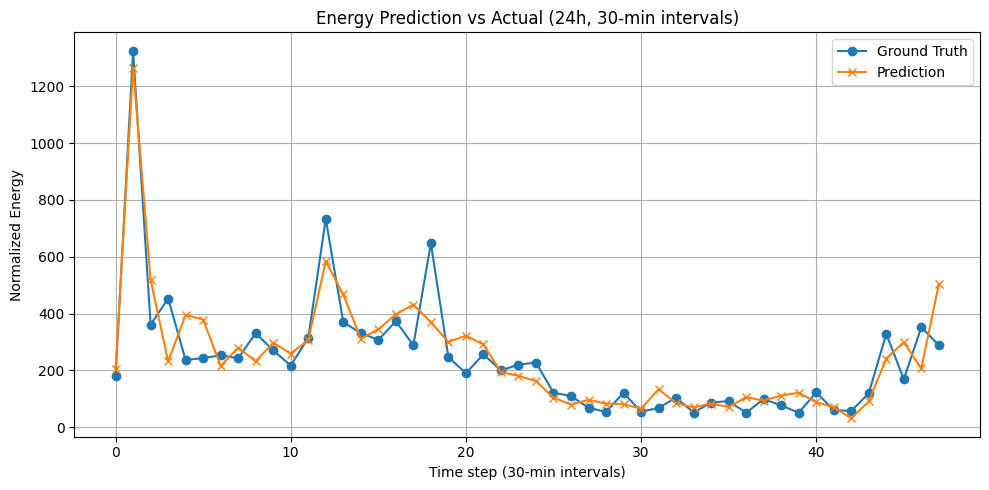

C:\Users\Kelsier\AppData\Local\Temp\ipykernel_16908\2884819306.py:24: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['energy_lag_48'] = df['total_energy'].shift(48).fillna(method='bfill')
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_16908\2884819306.py:25: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['energy_lag_96'] = df['total_energy'].shift(96).fillna(method='bfill')
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_16908\2884819306.py:26: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['energy_lag_1'] = df['total_energy'].shift(1).fillna(method='bfill')
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_16908\2884819306.py:27: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Us

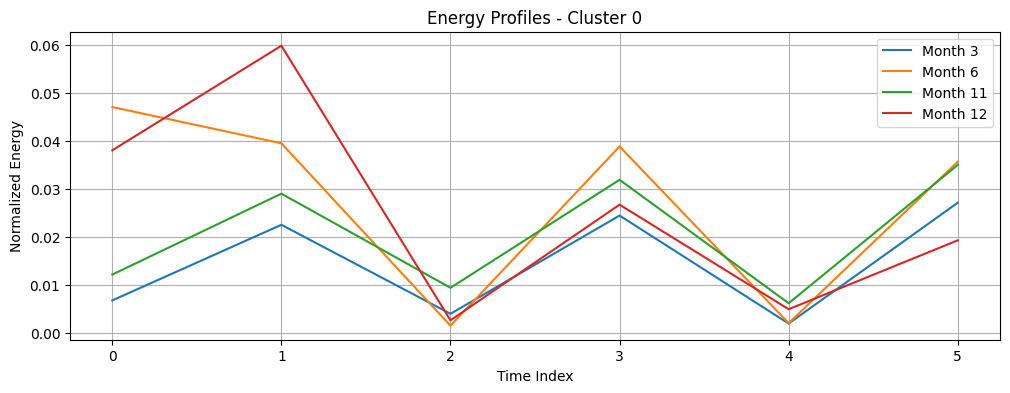

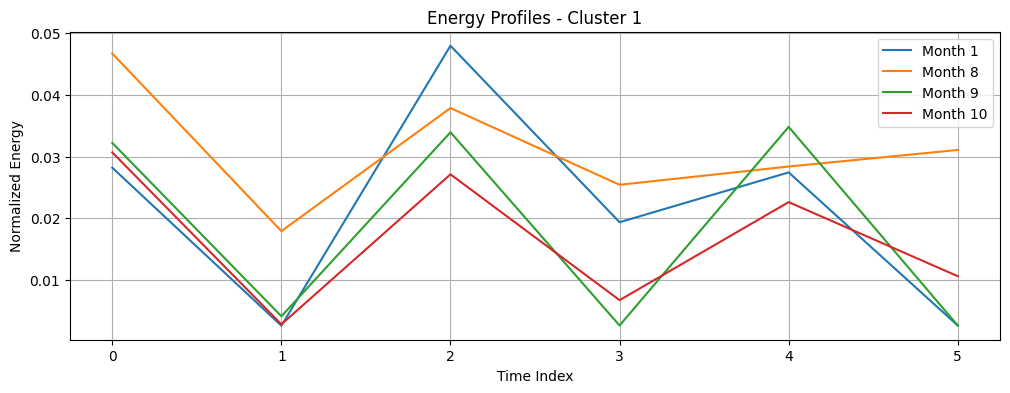

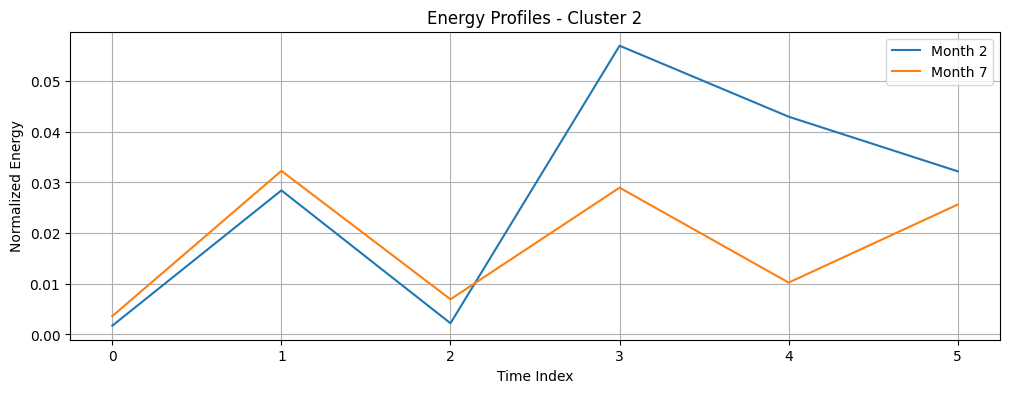

C:\Users\Kelsier\AppData\Local\Temp\ipykernel_16908\3314992363.py:60: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['rolling_mean_6'] = df['total_energy'].rolling(8).mean().fillna(method='bfill')
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_16908\3314992363.py:61: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['rolling_std_6'] = df['total_energy'].rolling(8).std().fillna(method='bfill')
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_16908\3314992363.py:62: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['energy_lag_336'] = df['total_energy'].shift(336).fillna(method='bfill')
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_16908\3314992363.py:63: FutureWarning: Series.fillna with 'method' is deprecated and will raise in 

Epoch 1/100 | Train Loss: 0.002922 | Val Loss: 0.002665
Epoch 2/100 | Train Loss: 0.002742 | Val Loss: 0.002555
Epoch 3/100 | Train Loss: 0.002676 | Val Loss: 0.002578
Epoch 4/100 | Train Loss: 0.002649 | Val Loss: 0.002518
Epoch 5/100 | Train Loss: 0.002625 | Val Loss: 0.002499
Epoch 6/100 | Train Loss: 0.002604 | Val Loss: 0.002482
Epoch 7/100 | Train Loss: 0.002581 | Val Loss: 0.002461
Epoch 8/100 | Train Loss: 0.002552 | Val Loss: 0.002440
Epoch 9/100 | Train Loss: 0.002521 | Val Loss: 0.002396
Epoch 10/100 | Train Loss: 0.002482 | Val Loss: 0.002360
Epoch 11/100 | Train Loss: 0.002446 | Val Loss: 0.002348
Epoch 12/100 | Train Loss: 0.002392 | Val Loss: 0.002293
Epoch 13/100 | Train Loss: 0.002360 | Val Loss: 0.002259
Epoch 14/100 | Train Loss: 0.002290 | Val Loss: 0.002287
Epoch 15/100 | Train Loss: 0.002237 | Val Loss: 0.002203
Epoch 16/100 | Train Loss: 0.002180 | Val Loss: 0.002118
Epoch 17/100 | Train Loss: 0.002109 | Val Loss: 0.002063
Epoch 18/100 | Train Loss: 0.002058 | Va

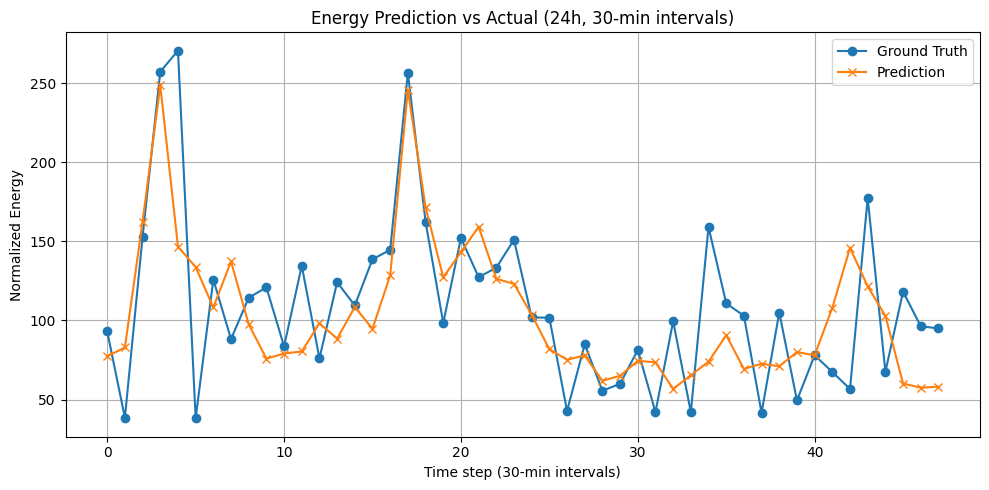

In [3]:
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
import seaborn as sns
import calendar
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import mean_absolute_error, r2_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def denormalize(norm_vals, original_min, original_max):
    return norm_vals * (original_max - original_min) + original_min

for file in os.listdir(file_path):
    full_path = os.path.join(file_path, file)
    if file == 'E_152.csv':
        continue
    df = feature_engineer(full_path)
    energy_min = df['total_energy'].min()
    energy_max = df['total_energy'].max()
    temp_min = df['Tout'].min()
    temp_max = df['Tout'].max()
    for col in ['total_energy', 'Tout']:
        min_val = df[col].min()
        max_val = df[col].max()
        df[col] = (df[col] - min_val) / (max_val - min_val)
    monthly_groups = df['total_energy'].groupby(df.index.month)

    min_len = min(len(group) for _, group in monthly_groups)

    monthly_profiles = np.vstack([
        group.values[:min_len] for _, group in monthly_groups
    ])

    k = 3
    kmeans = KMeans(n_clusters=k, random_state=42)
    clusters = kmeans.fit_predict(monthly_profiles)
    available_months = sorted(df.index.month.unique())
    month_cluster_map = dict(zip(available_months, clusters))
    df['cluster'] = df.index.month.map(month_cluster_map)
    for cluster_id in np.unique(clusters):
        cluster_months = [m for m, c in month_cluster_map.items() if c == cluster_id]
        plt.figure(figsize=(12, 4))
        
        for m in cluster_months:
            energy = df[df.index.month == m]['total_energy'].values[:min_len]  # trunc to min_len
            plt.plot(energy, label=f'Month {m}')
        
        plt.title(f'Energy Profiles - Cluster {cluster_id}')
        plt.xlabel('Time Index')
        plt.ylabel('Normalized Energy')
        plt.legend()
        plt.grid(True)
        plt.show()

    features = ['total_energy', 'Tout',  'month_sin', 'month_cos', 'day_of_week', 'hour_sin', 'hour_cos', 'is_weekend', 'cluster', 'energy_lag_48','energy_diff', 'max_energy', 'rolling_mean_6', 'rolling_std_6']
    df['rolling_mean_6'] = df['total_energy'].rolling(8).mean().fillna(method='bfill')
    df['rolling_std_6'] = df['total_energy'].rolling(8).std().fillna(method='bfill')
    df['energy_lag_336'] = df['total_energy'].shift(336).fillna(method='bfill')
    df['Tout_mean'] = df['Tout'].rolling(6).mean().fillna(method='bfill')
    df['energy_lag_336'] = (df['energy_lag_336'] - energy_min) / (energy_max - energy_min)
    df['energy_lag_48'] = (df['energy_lag_48'] - energy_min) / (energy_max - energy_min)
    df['energy_diff'] = (df['energy_diff'] - energy_min) / (energy_max - energy_min)
    df['max_energy'] = (df['max_energy'] - energy_min) / (energy_max - energy_min)
    df['Tout_diff'] = (df['Tout_diff'] - temp_min) / (temp_max - temp_min)
    df['Tout_mean'] = (df['Tout_mean'] - temp_min) / (temp_max - temp_min)
    df['rolling_std_6'] = (df['rolling_std_6'] - energy_min) / (energy_max - energy_min)
    df['rolling_mean_6'] = (df['rolling_mean_6'] - energy_min) / (energy_max - energy_min)
    data = df[features].values
    X, y = create_mimo_sequences(data, input_len=48)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)

    # Convert to tensors
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

    train_ds = TensorDataset(X_train_tensor, y_train_tensor)
    test_ds = TensorDataset(X_test_tensor, y_test_tensor)

    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)
    class KCNNLSTM(nn.Module):
        def __init__(self, input_features, conv_out=256, lstm_hidden=256, output_len=48):
            super(KCNNLSTM, self).__init__()
            self.conv = nn.Conv1d(input_features, conv_out, kernel_size=2, padding='same')
            self.relu = nn.ReLU()
            self.lstm = nn.LSTM(conv_out, lstm_hidden, batch_first=True)
            self.dropout = nn.Dropout(0.2)
            self.fc1 = nn.Linear(lstm_hidden, 64)
            self.fc2 = nn.Linear(64, output_len)

        def forward(self, x):
            x = x.permute(0, 2, 1)  
            x = self.conv(x)
            x = self.relu(x)
            x = x.permute(0, 2, 1)  
            lstm_out, _ = self.lstm(x)
            x = lstm_out[:, -1, :]
            x = self.fc1(x)
            x = self.fc2(x)
            return x
        
    model = KCNNLSTM(input_features=X_train.shape[2]).to(device)
    loss_fn = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    n_epochs = 100
    for epoch in range(n_epochs):
        model.train()
        train_losses = []

        for xb, yb in train_loader:
            optimizer.zero_grad()
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            loss = loss_fn(preds, yb)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        # Validation
        model.eval()
        val_losses = []
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(device), yb.to(device)
                preds = model(xb)
                loss = loss_fn(preds, yb)
                val_losses.append(loss.item())

        avg_train_loss = np.mean(train_losses)
        avg_val_loss = np.mean(val_losses)
        print(f"Epoch {epoch+1}/{n_epochs} | Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f}")
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb) 
            all_preds.append(preds.cpu().numpy())
            all_targets.append(yb.cpu().numpy())
        sample_idx = 9
        true_vals = yb[sample_idx].cpu().numpy()
        pred_vals = preds[sample_idx].cpu().numpy()
        y_pred = np.concatenate(all_preds, axis=0)
        y_true = np.concatenate(all_targets, axis=0)
        y_true = denormalize(y_true, energy_min, energy_max)
        y_pred = denormalize(y_pred, energy_min, energy_max)
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)

        print(f"\n🔍 Final Evaluation on Test Set:")
        print(f"MAE: {mae:.4f}")
        print(f"R²: {r2:.4f}")
        plt.figure(figsize=(10, 5))
        true_vals = denormalize(true_vals, energy_min, energy_max)
        pred_vals = denormalize(pred_vals, energy_min, energy_max)
        plt.plot(true_vals, label='Ground Truth', marker='o')
        plt.plot(pred_vals, label='Prediction', marker='x')
        plt.title("Energy Prediction vs Actual (24h, 30-min intervals)")
        plt.xlabel("Time step (30-min intervals)")
        plt.ylabel("Normalized Energy")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()